In [4]:
import os
import json
from csv import DictReader
from typing import Dict
from taxonomy import *
from sklearn.metrics import cohen_kappa_score

bugs_directory = "../../results/ESEM_26/bug_reports"
csv_path = "../../results/ESEM_26/classifications.csv"

bugs = set()
classification = {}
llm_classification = []
human_verification = []
product = set()
family = set()
transformation = set()
infer_types = set()
clang_types = set()
typechef_types = set()
individual_rater: dict[str, tuple[list[str], list[str]]] = {}
# Read in classifications
with open(csv_path, 'r') as csv_file:
    lines = csv_file.readlines()
    csv_reader = DictReader(lines)
    for row in csv_reader:
        if 'TRUE_NEW' in row['Agreed Classification']:
            classification[row['id']] = 'TRUE_NEW'
        elif 'TRUE' in row['Agreed Classification']:
            classification[row['id']] = 'TRUE'
        else:
            classification[row['id']] = 'FALSE'
        if row['Verifier'] not in individual_rater:
            individual_rater[row['Verifier']] = (list(), list())
        if 'TRUE_NEW' in row['LLM Classification']:
            llm = 'true_new'
        elif 'TRUE' in row['LLM Classification']:
            llm = 'true'
        else:
            llm = 'false'
        if 'TRUE_NEW' in row['Human Verification Result']:
            human = 'true_new'
        elif 'TRUE' in row['Human Verification Result']:
            human = 'true'
        else:
            human = 'false'
        individual_rater[row['Verifier']][0].append(llm)
        individual_rater[row['Verifier']][1].append(human)
        llm_classification.append(llm)
        human_verification.append(human)
        # Ids where Mohammad disagreed with the LLM
        if row['Verifier'] == 'Mohammad' and llm != human:
            print(f"Disagreement for id {row['id']}: LLM classified as {llm}, human classified as {human}")

for verifier, (llm_labels, human_labels) in individual_rater.items():
    kappa = cohen_kappa_score(llm_labels, human_labels)
    print(f"Cohen's Kappa for {verifier}: {kappa}")
kappa = cohen_kappa_score(llm_classification, human_verification)
print(f"Cohen's Kappa: {kappa}")

# Deduplicate bugs. Build a few structures:
bug_data = []
for filename in os.listdir(bugs_directory):
    if filename.endswith(".json") and "#" not in filename:
        with open(os.path.join(bugs_directory, filename), 'r') as json_file:
            bug_data.append(json.load(json_file))

# Resolve some discrepancies in the data; map each bug to a common taxonomy
for data in bug_data:
    bug_id = data['id']
    data['classification'] = classification[bug_id]
    if 'err' in data:
        data['tool'] = 'typechef'
        data['strategy'] = 'family'
        data['type'] = get_warning_type(data)
        typechef_types.add(data['type'])
    elif data['originalAlarm']['alarmType'].isupper():
        data['tool'] = 'infer'
        data['type'] = get_warning_type(data)
        infer_types.add(data['type'])
    else:
        data['tool'] = 'clang'
        data['type'] = get_warning_type(data)
        clang_types.add(data['type'])

# Print out the types found by each tool
print(f"Infer types: {infer_types}")
print(f"Clang types: {clang_types}")
print(f"TypeChef types: {typechef_types}")

# Sanity check: Group bugs by line number, file, and type, and see if we have multiple classifications for the same bug
sanity_check: Dict[tuple, set] = {}
bugs_to_ids: Dict[tuple, set] = {}
keys_to_classifications: Dict[tuple, set] = {}
for data in bug_data:
    if data['strategy'] == 'family':
        line = data['line_number']
        lines = [line, line]
        file = os.path.basename(data['input_file'])
    elif data['strategy'] == 'product':
        line = data['originalAlarm']['line']
        lines = [line, line]
        file = os.path.basename(data['originalAlarm']['fileLocation'])
    else:
        lines = data['lineInputFile']
        file = os.path.basename(data['originalFile'])
    key = (file, tuple(lines), data['type'])
    key_with_classification = (file, tuple(lines), data['type'], data['classification'])
    bugs.add(key_with_classification)
    if key not in sanity_check:
        sanity_check[key] = set()
    if key not in bugs_to_ids:
        bugs_to_ids[key] = set()
    sanity_check[key].add(data['classification'])
    bugs_to_ids[key].add(data['id'])
    if key not in keys_to_classifications:
        keys_to_classifications[key] = set()
    keys_to_classifications[key].add(data['classification'])
    if data['strategy'] == 'family':
        family.add(key_with_classification)
    elif data['strategy'] == 'product':
        product.add(key_with_classification)
    else:
        transformation.add(key_with_classification)

print(f"Total bugs: {len(bugs)}")

Disagreement for id PRODUCT_1: LLM classified as false, human classified as true_new
Disagreement for id PRODUCT_3: LLM classified as false, human classified as true_new
Disagreement for id PRODUCT_6: LLM classified as true_new, human classified as false
Disagreement for id PRODUCT_7: LLM classified as true_new, human classified as false
Disagreement for id PRODUCT_9: LLM classified as true_new, human classified as false
Disagreement for id PRODUCT_10: LLM classified as true, human classified as false
Disagreement for id PRODUCT_11: LLM classified as true_new, human classified as false
Disagreement for id PRODUCT_12: LLM classified as false, human classified as true_new
Disagreement for id PRODUCT_14: LLM classified as true_new, human classified as false
Disagreement for id PRODUCT_15: LLM classified as true, human classified as false
Disagreement for id PRODUCT_17: LLM classified as true_new, human classified as false
Disagreement for id PRODUCT_18: LLM classified as true_new, human c

In [2]:


disagreements: list[tuple[str, str]]= []
for key, classifications in sanity_check.items():
    if len(classifications) > 1:
        matching_bugs = bugs_to_ids[key]
        dis = []
        for m in matching_bugs:
            dis.append((m, classification[m]))
        disagreements.append(dis)
print(f"Number of disagreements: {len(disagreements)}")
for disagreement in disagreements:
    # Compute the majority classification for this bug
    true_classifications = 0
    false_classifications = 0
    for _, c in disagreement:
        if 'TRUE' in c:
            true_classifications += 1
        else:
            false_classifications += 1
    print(disagreement)
    majority_classification = ""
    if true_classifications > false_classifications:
        majority_classification = f'TRUE ({true_classifications} TRUE vs {false_classifications} FALSE)'
    elif false_classifications > true_classifications:
        majority_classification = f'FALSE ({false_classifications} FALSE vs {true_classifications} TRUE)'
    else:
        majority_classification = 'TIE'   
    
    print(f"Majority classification: {majority_classification}")
    print()

Number of disagreements: 24
[('PRODUCT_141', 'TRUE_NEW'), ('PRODUCT_136', 'FALSE'), ('PRODUCT_67', 'TRUE_NEW'), ('PRODUCT_201', 'FALSE'), ('PRODUCT_192', 'FALSE'), ('TRANSFORMATION_119', 'TRUE_NEW'), ('PRODUCT_166', 'TRUE_NEW'), ('PRODUCT_6', 'TRUE_NEW'), ('PRODUCT_145', 'TRUE_NEW'), ('PRODUCT_114', 'TRUE_NEW'), ('PRODUCT_82', 'TRUE_NEW'), ('PRODUCT_209', 'FALSE'), ('PRODUCT_207', 'TRUE_NEW'), ('PRODUCT_143', 'TRUE_NEW'), ('PRODUCT_193', 'FALSE'), ('PRODUCT_189', 'FALSE'), ('PRODUCT_84', 'FALSE'), ('PRODUCT_107', 'TRUE_NEW'), ('PRODUCT_106', 'TRUE_NEW'), ('FAMILY_38', 'TRUE_NEW'), ('PRODUCT_161', 'TRUE_NEW'), ('PRODUCT_52', 'FALSE'), ('PRODUCT_131', 'TRUE_NEW'), ('TRANSFORMATION_3', 'TRUE_NEW'), ('PRODUCT_144', 'TRUE_NEW'), ('PRODUCT_206', 'TRUE_NEW'), ('PRODUCT_78', 'TRUE_NEW'), ('PRODUCT_199', 'TRUE_NEW')]
Majority classification: TRUE (20 TRUE vs 8 FALSE)

[('PRODUCT_191', 'TRUE_NEW'), ('TRANSFORMATION_142', 'TRUE_NEW'), ('PRODUCT_64', 'TRUE_NEW'), ('TRANSFORMATION_59', 'FALSE'), ('

Number of true bugs: 113
Number of TRUE_NEW bugs: 77
Number of false bugs: 82
Product-based recall: 0.39080459770114945
Product-based adjusted recall: 0.5112781954887218
Product-based precision: 0.85
Transformation-based recall: 0.28160919540229884
Transformation-based adjusted recall: 0.3684210526315789
Transformation-based precision: 0.45794392523364486
Family-based recall: 0.3333333333333333
Family-based adjusted recall: 0.43609022556390975
Family-based precision: 0.7837837837837838
False bugs found by product-based approach: 12
False bugs found by transformation-based approach: 58
False bugs found by family-based approach: 16


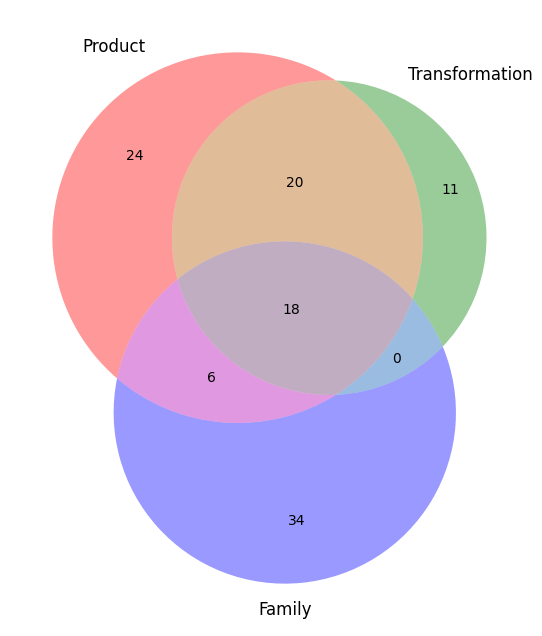

In [8]:
# Stats
# Number of true bugs
true_bugs = set(filter(lambda x: 'TRUE' in x[3], bugs))
print(f"Number of true bugs: {len(true_bugs)}")

# Number of TRUE_NEW bugs
true_new_bugs = set(filter(lambda x: 'TRUE_NEW' in x[3], bugs))
print(f"Number of TRUE_NEW bugs: {len(true_new_bugs)}")

# Number of FALSE bugs
false_bugs = set(filter(lambda x: 'FALSE' in x[3], bugs))
print(f"Number of false bugs: {len(false_bugs)}")

total_true_bugs = len(true_new_bugs) + 97
findable_bugs = len(true_new_bugs) + 56
# Recall
# Product-based
product_true_bugs = set(filter(lambda x: 'TRUE' in x[3], product))
product_recall = len(product_true_bugs) / total_true_bugs
print(f"Product-based recall: {product_recall}")
product_adjusted_recall = len(product_true_bugs) / findable_bugs
print(f"Product-based adjusted recall: {product_adjusted_recall}")
product_precision = len(product_true_bugs) / len(product)
print(f"Product-based precision: {product_precision}")

# Transformation-based
transformation_true_bugs = set(filter(lambda x: 'TRUE' in x[3], transformation))
transformation_recall = len(transformation_true_bugs) / total_true_bugs
print(f"Transformation-based recall: {transformation_recall}")
transformation_adjusted_recall = len(transformation_true_bugs) / findable_bugs
print(f"Transformation-based adjusted recall: {transformation_adjusted_recall}")
transformation_precision = len(transformation_true_bugs) / len(transformation)
print(f"Transformation-based precision: {transformation_precision}")

# Family-based
family_true_bugs = set(filter(lambda x: 'TRUE' in x[3], family))
family_recall = len(family_true_bugs) / total_true_bugs
print(f"Family-based recall: {family_recall}")
family_adjusted_recall = len(family_true_bugs) / findable_bugs
print(f"Family-based adjusted recall: {family_adjusted_recall}")
family_precision = len(family_true_bugs) / len(family)
print(f"Family-based precision: {family_precision}")

# False bugs found by each approach
product_false = set(filter(lambda x: 'FALSE' in x[3], product))
transformation_false = set(filter(lambda x: 'FALSE' in x[3], transformation))
family_false = set(filter(lambda x: 'FALSE' in x[3], family))
print(f"False bugs found by product-based approach: {len(product_false)}")
print(f"False bugs found by transformation-based approach: {len(transformation_false)}")
print(f"False bugs found by family-based approach: {len(family_false)}")
# Create the venn diagram
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
fig, ax = plt.subplots(figsize=(8, 8))
venn3(subsets=(set(filter(lambda x: 'TRUE' in x[3], product)),
               set(filter(lambda x: 'TRUE' in x[3], transformation)),
               set(filter(lambda x: 'TRUE' in x[3], family))), set_labels=('Product', 'Transformation', 'Family'), ax=ax)
plt.savefig("/Users/austin/git/sugarlyzer-paper/resources/vbdb_tps.png", dpi=300, bbox_inches='tight')
plt.show()